# Level 1 · Part 2 — Which segmentation can we trust?

The vendor ships one segmentation of this MERSCOPE section, but segmentation is a *choice*,
not ground truth. Here we **re-segment the same image four ways** and ask a concrete question:
**how many of the measured transcripts does each method actually place inside a cell, and are
those cells clean?**

We work on one 1000 µm crop of the cortical band (enough tissue to cross layers and see several
lineages), run four segmentations, then compare them on two axes:

1. **How much signal is captured** — the fraction of transcripts assigned to a cell.
2. **How clean the cells are** — *negative-marker purity* (do cells co-express genes from
   mutually-exclusive lineages, i.e. did transcripts leak across boundaries?).

## 0. Setup

In [1]:
import shutil

import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

import spatialdata as sd
import spatialdata_plot  # noqa: F401  (registers the `.pl` plotting accessor)
import sopa
from spatialdata import bounding_box_query
from spatialdata.models import Image2DModel, ShapesModel, TableModel, get_table_keys
from spatialdata.transformations import get_transformation

import l1_utils  # Level-1 helpers (this folder)
from spatialbrain import FilePaths  # project path helper

import warnings

warnings.simplefilter("ignore")  # keep the teaching output readable (zarr/dask notices)
sc.settings.verbosity = 1

### Where does the data live — and where do *you* write?

The baseline section is **staged once, read-only, and shared** by everyone on the course. You
never write there. Your own crop and segmentations go in **your clone's git-ignored `data/`
folder**, via the project's `FilePaths` helper — so your outputs stay next to your analysis and
never touch the shared copy (or git).

In [2]:
# Staged, read-only, shared — NEVER write here.
SHARED_ZARR = (
    "/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/"
    "data/wang2025_merfish/processed/UCSF2018-003-MFG_baseline.zarr"
)
# An independent reference of the same tissue, with broad lineage labels only — used later to
# derive the marker pairs for the purity metric.
SHARED_REF = (
    "/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/"
    "data/wang2025_multiome/processed/wang2025_multiome_rna_panel_ref.h5ad"
)

# Your OWN writable copy, in the repo's git-ignored data/ dir.
paths = FilePaths.dataset("wang2025_merfish").create()
CROP_ZARR = paths.processed / "crop_C.zarr"
print("your crop will be written to:", CROP_ZARR.relative_to(FilePaths.ROOT))

your crop will be written to: data/wang2025_merfish/processed/crop_C.zarr


## 1. Make the crop

We read the full section, then cut a **1000 µm square** on the cortical band. `'global'` is the
image's pixel space; the transcripts and cell polygons are micron-native and carry a micron→pixel
affine, so we take the pixel-per-micron scale from that affine to size the crop.

In [3]:
sdata = sd.read_zarr(SHARED_ZARR)
image_key = list(sdata.images)[0]
points_key = next(k for k in sdata.points if "patch" not in k.lower())

# 'global' == PIXEL space; the micron->pixel scale comes from the transcripts' affine.
aff = get_transformation(sdata[points_key], get_all=True)["global"]
px_per_um = abs(float(aff.to_affine_matrix(input_axes=("x", "y"), output_axes=("x", "y"))[0, 0]))

# Crop C (fixed for the course): 1000 um square, centred on the cortical band (pixel coords).
CX_PX, CY_PX, CROP_UM = 88000, 33000, 1000
half = px_per_um * CROP_UM / 2
cmin = [CX_PX - half, CY_PX - half]
cmax = [CX_PX + half, CY_PX + half]
print(f"px/um = {px_per_um:.3f}  ->  {CROP_UM} um = {2 * half:.0f} px")

px/um = 9.259  ->  1000 um = 9259 px


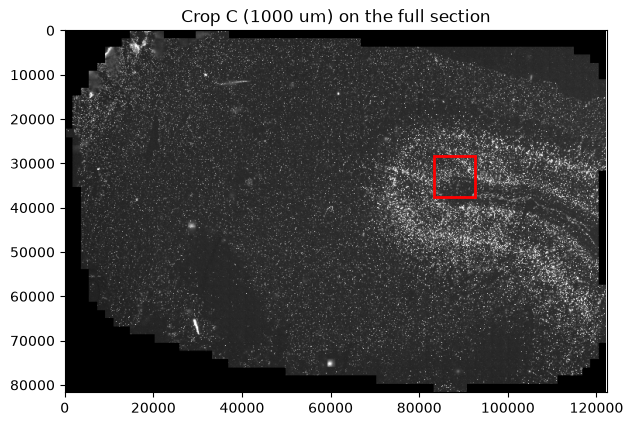

In [4]:
# Where does the crop sit on the whole section?
# Set the display contrast from a percentile (the tissue is dim with a few bright spots), as in Part 1.
import matplotlib.colors as mcolors

coarse = sdata[image_key]["scale4"]["image"]
dapi_norm = mcolors.Normalize(0, float(np.percentile(np.asarray(coarse.sel(c=0)), 99.5)))

fig, ax = plt.subplots(figsize=(7, 5))
sdata.pl.render_images(image_key, channel=0, cmap="gray", norm=dapi_norm, colorbar=False).pl.show(
    ax=ax, title=f"Crop C ({CROP_UM} um) on the full section"
)
ax.add_patch(Rectangle((cmin[0], cmin[1]), 2 * half, 2 * half, edgecolor="red", facecolor="none", lw=2))

In [5]:
crop = bounding_box_query(
    sdata,
    axes=("x", "y"),
    min_coordinate=cmin,
    max_coordinate=cmax,
    target_coordinate_system="global",
    filter_table=True,  # subset the vendor table to the cropped cells -> table & shapes stay in sync
)

# Name the two image channels so the segmenters can refer to them by name (DAPI / PolyT).
img = crop[image_key]
full = img["scale0"]["image"]
crop[image_key] = Image2DModel.parse(
    full.data,
    dims=tuple(full.dims),
    c_coords=["DAPI", "PolyT"],
    scale_factors=[2, 2, 2, 2],
    transformations=get_transformation(img, get_all=True),
)

# Write YOUR crop to YOUR data/ dir (overwrite any previous run).
shutil.rmtree(CROP_ZARR, ignore_errors=True)
crop.write(CROP_ZARR)
print("wrote", CROP_ZARR)
print("shapes:", list(crop.shapes))  # 'authors_cells' = the vendor segmentation
crop

wrote /shared/home/tp185001/github/cajal-project15-spatial-brain/.claude/worktrees/distracted-curie-aa132e/data/wang2025_merfish/processed/crop_C.zarr
shapes: ['authors_cells']


SpatialData object, with associated Zarr store: /shared/home/tp185001/github/cajal-project15-spatial-brain/.claude/worktrees/distracted-curie-aa132e/data/wang2025_merfish/processed/crop_C.zarr
├── Images
│     └── 'raw_UCSF2018-003-MFG_z3': DataTree[cyx] (2, 9260, 9260), (2, 4630, 4630), (2, 2315, 2315), (2, 1157, 1157), (2, 578, 578)
├── Points
│     └── 'raw_UCSF2018-003-MFG_transcripts': DataFrame with shape: (<Delayed>, 8) (3D points)
├── Shapes
│     └── 'authors_cells': GeoDataFrame shape: (1552, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (1552, 300)
with coordinate systems:
    ▸ 'global', with elements:
        raw_UCSF2018-003-MFG_z3 (Images), raw_UCSF2018-003-MFG_transcripts (Points), authors_cells (Shapes)
with the following Dask-backed elements not being self-contained:
    ▸ raw_UCSF2018-003-MFG_z3: /shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/data/wang2025_merfish/processed/UCSF2018-003-MFG_baseline.zarr/images/raw_UCSF2018-003-MFG_z3

## 2. Run the four segmentations  (~10 minutes)

All four are driven by `l1_utils` (CPU, process-parallel across image patches — the course has no
GPU). **CellPose** segments whole cells from the poly(T) channel (`PolyT`, ≈ cytoplasm) + DAPI
(nucleus) at a ~96 px (≈10 µm) diameter; **Baysor** and **Proseg** then refine that CellPose prior
using the transcripts. Each writes its boundaries back into your crop's `.zarr`.

In [6]:
n_cellpose = l1_utils.run_cellpose(str(CROP_ZARR), diameter=96)
print("CellPose:", n_cellpose, "cells")

CellPose: 2211 cells


In [7]:
n_baysor = l1_utils.run_baysor(str(CROP_ZARR))
print("Baysor:", n_baysor, "cells")

[                                        ] | 0% Completed | 129.86 us

[                                        ] | 0% Completed | 102.21 ms

[                                        ] | 0% Completed | 203.40 ms

[####################                    ] | 50% Completed | 317.89 ms

[####################                    ] | 50% Completed | 428.42 ms

...

Reading transcript-segmentation outputs: 100%|██████████| 1/1 [00:01<00:00,  1.15s/it]

Resolving conflicts: 0it [00:00, ?it/s]

Resolving conflicts: 0it [00:00, ?it/s]

[INFO] (sopa.segmentation.methods.utils) Added sdata.tables['table'], and 2375 cell boundaries to sdata['baysor_boundaries']


Baysor: 2375 cells


In [8]:
n_proseg = l1_utils.run_proseg(str(CROP_ZARR))
print("Proseg:", n_proseg, "cells")

[                                        ] | 0% Completed | 228.58 us

[                                        ] | 0% Completed | 102.08 ms

[                                        ] | 0% Completed | 204.20 ms

[####################                    ] | 50% Completed | 305.71 ms

[####################                    ] | 50% Completed | 408.13 ms

...

Using 16 threads


Finished reading input


Read dataset:
   176981 transcripts
     2021 cells
      300 genes
       36 fovs


[INFO] (sopa.segmentation.methods._proseg) Proseg table and boundaries added (running `sopa.aggregate` is not mandatory).


Proseg: 2021 cells


In [9]:
sdata = sd.read_zarr(CROP_ZARR)  # reload to see all four segmentations
image_key = list(sdata.images)[0]
points_key = next(k for k in sdata.points if "patch" not in k.lower())
n_transcripts = int(sdata[points_key].shape[0].compute())

METHODS = {
    "Vendor": "authors_cells",  # the vendor's own (watershed) segmentation
    "CellPose": "cellpose_boundaries",
    "Baysor": "baysor_boundaries",  # CellPose prior, transcript-refined
    "Proseg": "proseg_boundaries",  # CellPose prior, transcript-refined
}
print(f"{n_transcripts:,} transcripts in the crop")
{label: (key in sdata.shapes) for label, key in METHODS.items()}

180,327 transcripts in the crop


{'Vendor': True, 'CellPose': True, 'Baysor': True, 'Proseg': True}

## 3. Look first — boundaries over DAPI

Before any metric, *look*. In a small window, overlay each method's cell outlines on the DAPI
nuclei. Notice how well-separated the cells are here — that will matter for the purity metric later.

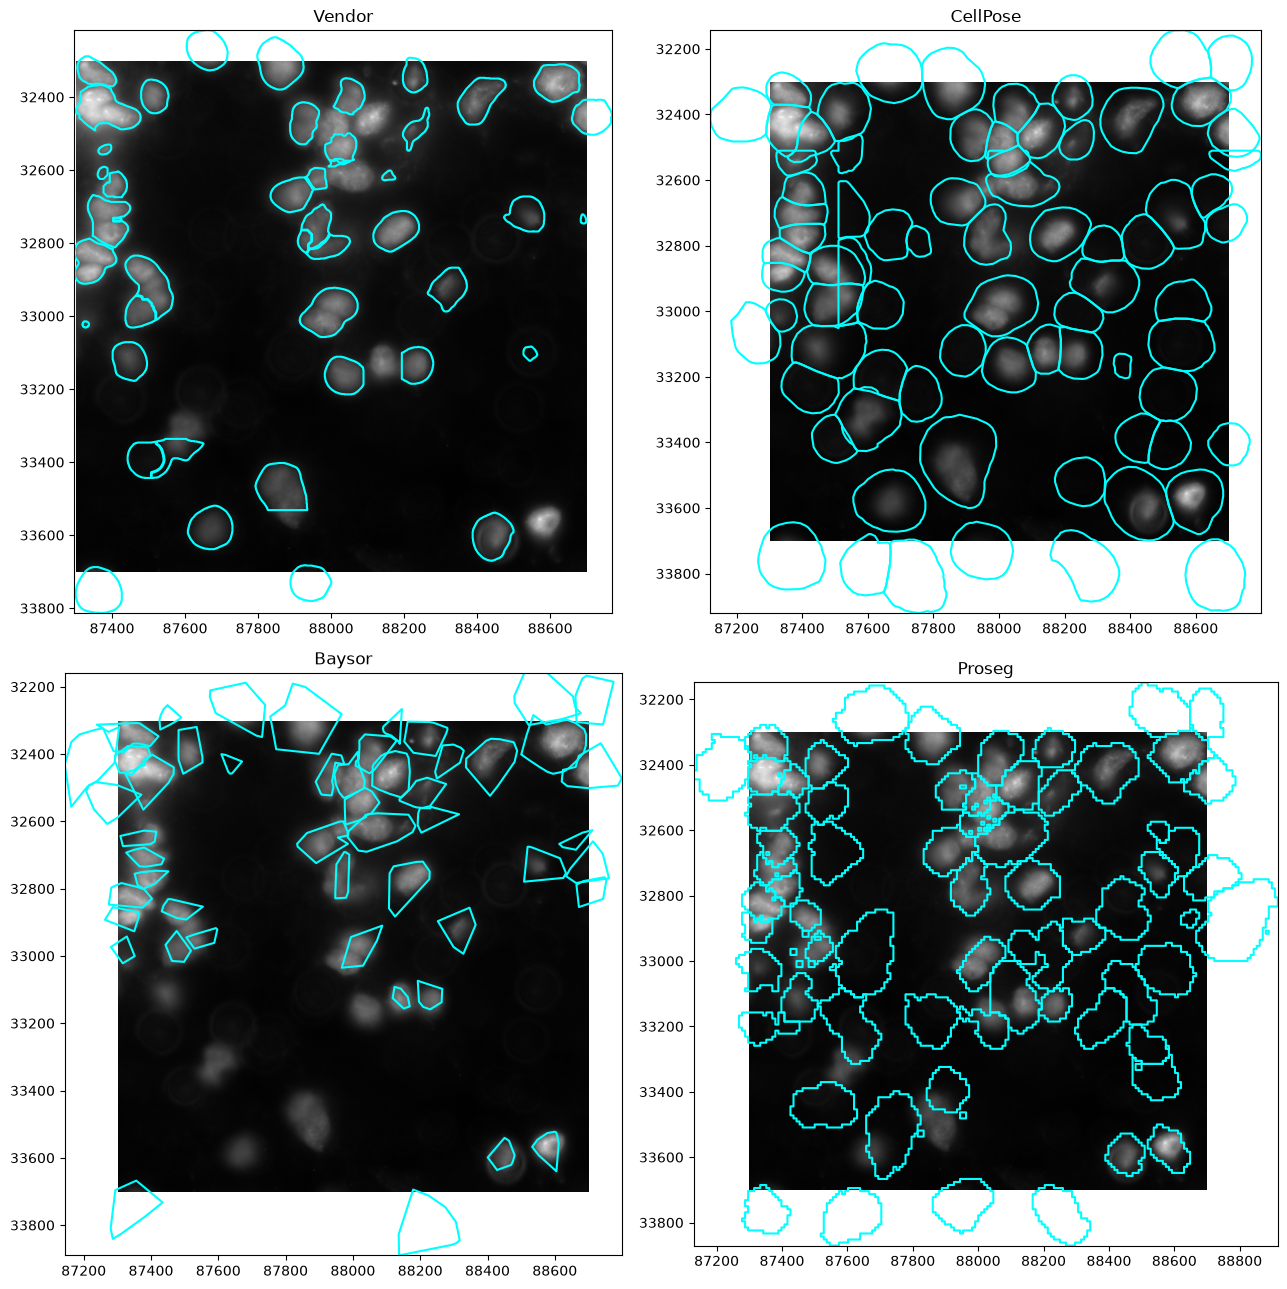

In [10]:
ext = sd.get_extent(sdata[image_key], coordinate_system="global")
cx = 0.5 * (ext["x"][0] + ext["x"][1])
cy = 0.5 * (ext["y"][0] + ext["y"][1])
win = 700  # px (~75 um)
view = bounding_box_query(
    sdata,
    axes=("x", "y"),
    min_coordinate=[cx - win, cy - win],
    max_coordinate=[cx + win, cy + win],
    target_coordinate_system="global",
)

fig, axes = plt.subplots(2, 2, figsize=(13, 13))
for ax_, (label, key) in zip(axes.ravel(), METHODS.items(), strict=False):
    (
        view.pl.render_images(image_key, channel="DAPI", cmap="gray", colorbar=False)
        .pl.render_shapes(key, fill_alpha=0, outline_alpha=1, outline_color="cyan")
        .pl.show(ax=ax_, title=label)
    )
fig.tight_layout()

## 4. Assign transcripts and apply QC — identically for every method

For each segmentation we assign transcripts to cells with the **same** Sopa aggregation, then apply
the **same** post-hoc QC filter on three per-cell covariates:

- **`n_counts`** ≥ 10 transcripts
- **`n_genes`** ≥ 3 distinct genes
- **`area_um2`** ≥ 15 µm²  (area is converted to µm² for *every* method, so the units match even
  though CellPose polygons are in pixels and the transcript methods are in microns)

⚠️ **A caveat on fairness.** The transcript-based methods (**Baysor**, **Proseg**) already enforce
their *own* minimum molecules / area *during* segmentation, so this shared filter removes very few
of their cells — whereas the vendor and CellPose, which don't, lose more. The shared filter makes
the *post-hoc* criteria identical, but each method's built-in floor still differs; keep that in mind
when reading the kept-cell counts.

When we drop a cell we drop it from **both** the table and its polygons, so the two never fall out
of sync (this is exactly what Sopa does internally: `geo_df.loc[table.obs_names]`).

In [11]:
MIN_COUNTS, MIN_GENES, MIN_AREA_UM2 = 10, 3, 15  # identical thresholds for every method


def as_dense(a):
    X = a.layers["counts"] if "counts" in a.layers else a.X
    return np.asarray(X.todense()) if hasattr(X, "todense") else np.asarray(X)


tables = {}
counts_report = {}
assigned_total = {}  # transcripts assigned by each method BEFORE QC (the true "fraction assigned")
for label, shapes_key in METHODS.items():
    table_key = f"{shapes_key}_table"

    # (1) assign transcripts to this method's cells — same aggregation for all four
    sopa.aggregate(
        sdata,
        shapes_key=shapes_key,
        aggregate_genes=True,
        aggregate_channels=False,
        min_transcripts=0,
        key_added=table_key,
    )
    adata = sdata[table_key]
    adata.layers["counts"] = adata.X.copy()

    # (2) per-cell QC covariates — explicit, so you see exactly what we filter on
    X = as_dense(adata)
    assigned_total[label] = float(X.sum())  # every transcript this method placed in a cell (pre-QC)
    adata.obs["n_counts"] = X.sum(1)
    adata.obs["n_genes"] = (X > 0).sum(1)
    area = pd.Series(
        l1_utils.shapes_area_um2(sdata, shapes_key, points_key), index=sdata[shapes_key].geometry.index.astype(str)
    )
    adata.obs["area_um2"] = area.reindex(adata.obs_names.astype(str)).to_numpy()

    keep = (
        (adata.obs["n_counts"] >= MIN_COUNTS)
        & (adata.obs["n_genes"] >= MIN_GENES)
        & (adata.obs["area_um2"] >= MIN_AREA_UM2)
    )
    counts_report[label] = {"cells (raw)": adata.n_obs, "cells (kept)": int(keep.sum())}

    # (3) drop failing cells from the TABLE and its SHAPES together (stay in sync)
    reg, reg_key, inst_key = get_table_keys(adata)
    tbl = adata[keep.to_numpy()].copy()
    tbl.obs[reg_key] = tbl.obs[reg_key].cat.remove_unused_categories()
    tbl.uns.pop("spatialdata_attrs", None)
    geo = sdata[shapes_key]
    geo.index = geo.index.astype(str)
    sdata[shapes_key] = ShapesModel.parse(geo.loc[tbl.obs_names.astype(str)])
    sdata[table_key] = TableModel.parse(tbl, region=reg, region_key=reg_key, instance_key=inst_key)
    tables[label] = sdata[table_key]

pd.DataFrame(counts_report).T.loc[list(METHODS)]

[INFO] (sopa.aggregation.transcripts) Aggregating transcripts over 1552 cells


[                                        ] | 0% Completed | 136.16 us

[####################                    ] | 50% Completed | 125.77 ms

[########################################] | 100% Completed | 229.24 ms

[INFO] (sopa.aggregation.transcripts) Aggregating transcripts over 2211 cells


...

[####################                    ] | 50% Completed | 121.46 ms

[####################                    ] | 50% Completed | 225.11 ms

[####################                    ] | 50% Completed | 340.67 ms

[########################################] | 100% Completed | 442.32 ms

,cells (raw),cells (kept)
Vendor,1552,1096
CellPose,2211,1552
Baysor,2375,2299
Proseg,2021,1648


## 5. Compare the cells — size, counts, genes, density

How do the four segmentations differ in the *cells* they produce? We summarise the same per-cell
covariates Sopa uses when comparing segmentations — number of cells, cell density, transcripts and
genes per cell, and cell area (in µm², so pixel-based CellPose is comparable to the micron-based
transcript methods) — plus the fraction of transcripts each method assigns.

🔬 **TASK 5.1 — Summarise the four segmentations.** Build a table with, per method: number of cells,
cells/mm², median transcripts and genes per cell, median area, and the **fraction of transcripts
assigned** (`prop_assigned`). 💡 **HINT:** the pre-QC assigned totals are in `assigned_total` (from the
loop above) and the crop is 1 mm²; `prop_assigned[m] = assigned_total[m] / n_transcripts`. The next
plot (the "signal captured" bar) reads `prop_assigned`, so define it here.


In [12]:
crop_area_mm2 = (CROP_UM / 1000) ** 2  # 1000 um square -> 1 mm^2
# fraction assigned uses the PRE-QC totals (a transcript is "assigned" if any cell caught it),
# so a method isn't penalised for assigning to cells that later fail QC.
prop_assigned = {m: assigned_total[m] / n_transcripts for m in METHODS}

summary = (
    pd.DataFrame(
        {
            m: {
                "n_cells": tables[m].n_obs,
                "cells / mm^2": tables[m].n_obs / crop_area_mm2,
                "median transcripts/cell": tables[m].obs["n_counts"].median(),
                "median genes/cell": tables[m].obs["n_genes"].median(),
                "median area (um^2)": tables[m].obs["area_um2"].median(),
                "transcripts assigned (%)": 100 * prop_assigned[m],
            }
            for m in METHODS
        }
    )
    .T.loc[list(METHODS)]
    .round(1)
)
summary

,n_cells,cells / mm^2,median transcripts/cell,median genes/cell,median area (um^2),transcripts assigned (%)
Vendor,1096.0,1096.0,64.5,33.0,101.7,51.6
CellPose,1552.0,1552.0,72.0,38.0,228.0,80.5
Baysor,2299.0,2299.0,47.0,28.0,102.4,95.5
Proseg,1648.0,1648.0,68.5,36.0,179.0,85.8


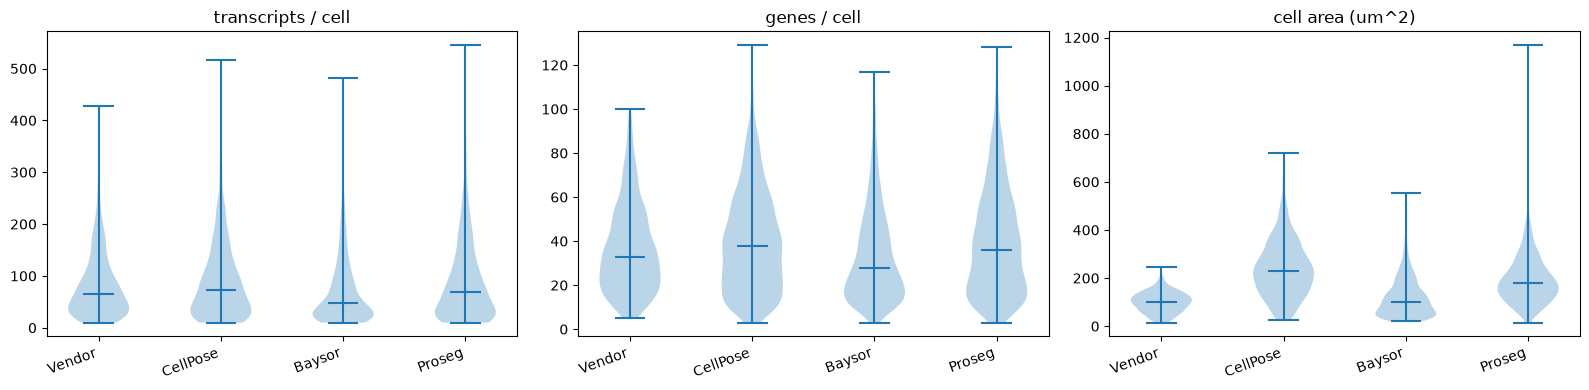

In [13]:
panels = [("transcripts / cell", "n_counts"), ("genes / cell", "n_genes"), ("cell area (um^2)", "area_um2")]
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax_, (title, col) in zip(axes, panels, strict=False):
    ax_.violinplot([tables[m].obs[col].to_numpy() for m in METHODS], showmedians=True)
    ax_.set_xticks(range(1, len(METHODS) + 1))
    ax_.set_xticklabels(list(METHODS), rotation=20, ha="right")
    ax_.set(title=title)
fig.tight_layout()

## 6. How much signal did each method capture?

The discriminating axis: the **fraction of all decoded transcripts that end up inside a cell**.
Same transcripts, same crop — only the segmentation differs.

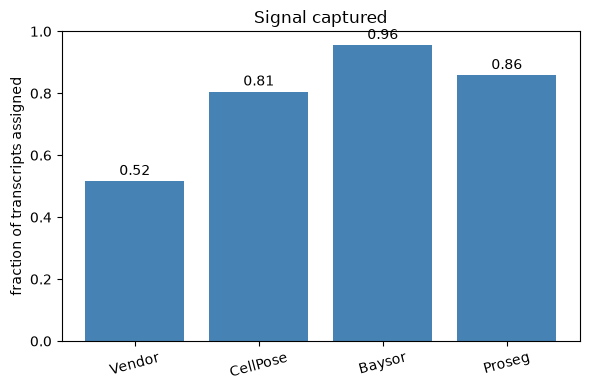

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))
labels = list(METHODS)
ax.bar(labels, [prop_assigned[m] for m in labels], color="steelblue")
ax.set(ylabel="fraction of transcripts assigned", title="Signal captured", ylim=(0, 1))
ax.tick_params(axis="x", rotation=15)
for i, m in enumerate(labels):
    ax.text(i, prop_assigned[m] + 0.02, f"{prop_assigned[m]:.2f}", ha="center")
fig.tight_layout()

## 7. A principled cleanliness check — negative-marker purity

More transcripts are only good if they land in the *right* cell. **Negative-marker purity** uses
pairs of genes from **mutually-exclusive lineages** (e.g. a neuron gene and a glia gene): a
correctly segmented cell should almost never be positive for both — co-expression means a boundary
leaked (the same cross-lineage co-expression we flagged as a doublet symptom in Part 1). We derive
the pairs from an independent lineage reference's broad cell-class labels (reproducible, not
hand-picked), then score each segmentation.

🔬 **TASK 7.1 — Score negative-marker purity.** Derive mutually-exclusive marker pairs from the
reference's broad lineage labels, then score each segmentation's cells. 💡 **HINT:**
`l1_utils.mutually_exclusive_markers_from_reference(ref, class_key="class")` returns the pairs, and
`l1_utils.negative_marker_purity(table, pairs, layer="counts")` returns the score — one call per method.

**Further reading — the metric.** Negative-marker purity comes from the imaging-based spatial
transcriptomics benchmarking literature: Salas et al., *Optimizing Xenium In Situ data utility*
(Nat. Methods 2025, [10.1038/s41592-025-02617-2](https://doi.org/10.1038/s41592-025-02617-2)), and
**ResolVI** (Ergen & Yosef, bioRxiv 2025,
[10.1101/2025.01.20.634005](https://doi.org/10.1101/2025.01.20.634005)), which also model
mis-assigned transcripts. We reimplement the ~30-line metric on CPU (we do *not* run ResolVI itself).


28 lineage markers -> 154 mutually-exclusive pairs


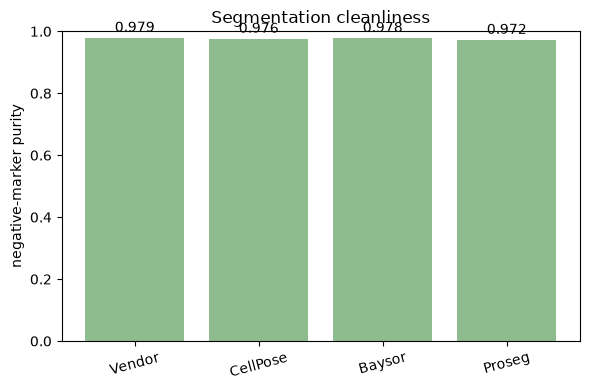

In [15]:
ref = ad.read_h5ad(SHARED_REF)
lineage_markers, pairs = l1_utils.mutually_exclusive_markers_from_reference(ref, class_key="class")
print(f"{sum(len(v) for v in lineage_markers.values())} lineage markers -> {len(pairs)} mutually-exclusive pairs")

purity = {m: l1_utils.negative_marker_purity(tables[m], pairs, layer="counts")[0] for m in METHODS}

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(labels, [purity[m] for m in labels], color="darkseagreen")
ax.set(ylabel="negative-marker purity", title="Segmentation cleanliness", ylim=(0, 1))
ax.tick_params(axis="x", rotation=15)
for i, m in enumerate(labels):
    ax.text(i, purity[m] + 0.02, f"{purity[m]:.3f}", ha="center")
fig.tight_layout()

❓ **What do you notice?** Purity is high **and essentially flat** across all four methods — it
barely separates them. Look back at the overlays in §3: the cells here are well-isolated, so
*any* reasonable segmentation is clean and there is little cross-lineage leakage to detect. Purity
is a **guard rail** (it would catch a badly over-merging segmentation) rather than the thing that
ranks methods on this tissue. The axis that *does* separate them is the signal captured in §5.

🚀 **Going further (optional — open-ended).**
- **Which lineage breaks each method?** Split purity (and transcripts/cell) *by lineage* and recompute
  per method. Does one method fail systematically on a particular morphology (large astrocytes vs small
  interneurons)? Defend a nuanced recommendation, not just an overall ranking.
- **Is the metric stable across the crop?** Divide the crop into tiles, recompute the metrics per tile
  per method, and map them. Which regions are hardest to segment, and could a region-aware choice ever
  beat a single global method?


## 8. What do the extra transcripts buy us? Compare the segmentations by eye.

More assigned transcripts mean more counts per cell — but do they translate into cleaner cell-type
structure? Build a UMAP from **each** method's counts and colour it by a few canonical lineage markers,
then judge for yourself. There is no scripted "right" answer here — look across all four panels and
form your own view.

❓ **QUESTION.** Which method gives the most clearly separated lineages — and is it the one that
captured the *most* transcripts? Does more signal always mean better-resolved structure, or can a
method that assigns fewer transcripts still show cleaner groups? What might explain what you see?


colouring UMAPs by: ['SATB2', 'AQP4', 'CLDN5']


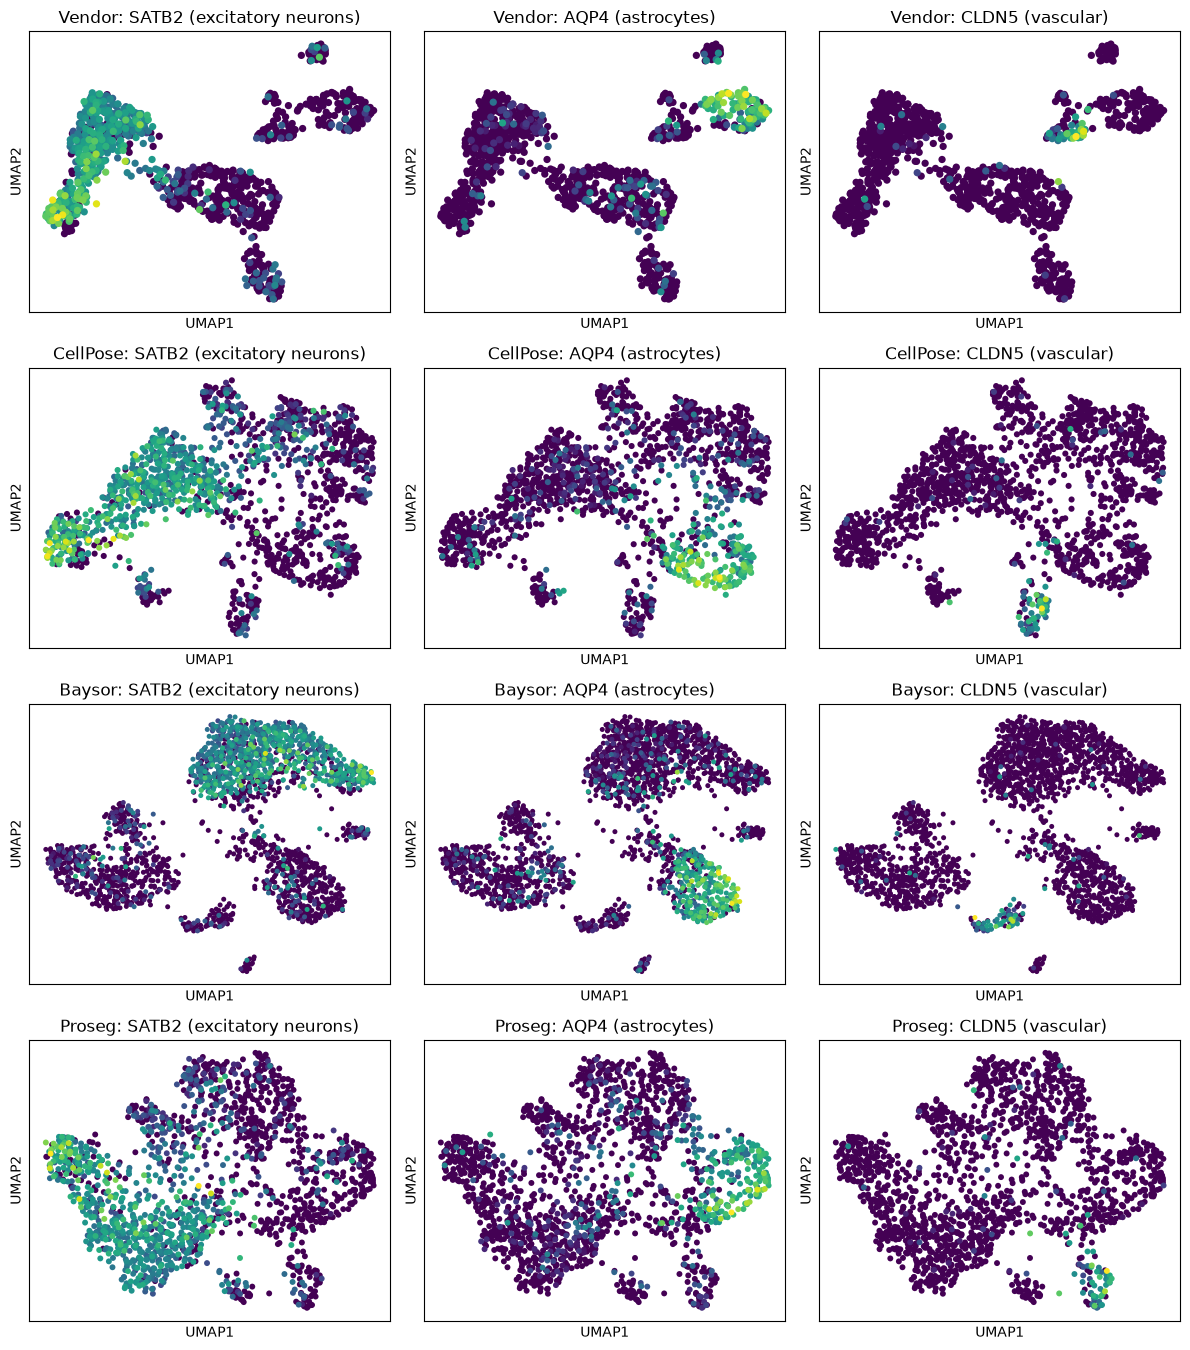

In [16]:
# canonical markers (same recognisable genes as Part 1), one per broad lineage
lineage_of = {"SATB2": "excitatory neurons", "AQP4": "astrocytes", "CLDN5": "vascular"}
marker_genes = [g for g in lineage_of if g in tables["Proseg"].var_names]
print("colouring UMAPs by:", marker_genes)

# Build a UMAP for EVERY method, so you can compare structure across all four (not just two).
umap_methods = list(METHODS)
embeds = {}
for m in umap_methods:
    a = tables[m].copy()
    a.X = a.layers["counts"].copy()
    sc.pp.normalize_total(a)
    sc.pp.log1p(a)
    sc.pp.pca(a, n_comps=30)
    sc.pp.neighbors(a)
    sc.tl.umap(a)
    embeds[m] = a

fig, axes = plt.subplots(len(umap_methods), len(marker_genes), figsize=(4 * len(marker_genes), 3.4 * len(umap_methods)))
for i, m in enumerate(umap_methods):
    for j, g in enumerate(marker_genes):
        sc.pl.umap(
            embeds[m], color=g, ax=axes[i, j], show=False, colorbar_loc=None, title=f"{m}: {g} ({lineage_of[g]})"
        )
fig.tight_layout()

## 9. Conclusion

- **Signal captured** separates the methods: on this crop the **Vendor** segmentation assigns the
  fewest transcripts and all three re-segmentations capture more — **Baysor** the most, then
  **Proseg**, then **CellPose** (still a clear gain over the vendor).
- But *where* those transcripts go differs. **Baysor** spreads them over the most — and smallest —
  cells, so it has the *fewest* counts per cell; **CellPose** makes fewer, larger cells with the
  *most* counts each; **Proseg** sits in between on both. Capturing more total signal can mean
  smaller or more numerous cells — there is no free lunch.
- **Purity** is high and flat everywhere (see the values on the bars) — on this well-separated
  tissue it confirms all segmentations are clean, but it doesn't rank them. It's a guard rail.
- The **UMAPs** let you compare structure across methods directly — inspect them and decide for
  yourself whether capturing more signal actually translates into cleaner lineage separation *here*.

There is no single "correct" segmentation — the right choice trades off total signal, cell count,
cell size, and runtime. The point is to *measure* the trade-off rather than trust the vendor default
blindly.
